# Anonymization Issues Investigation

This notebook helps investigate files that were not properly anonymized.

**Usage:**
1. Set the paths in the Configuration cell
2. Run all cells to load and analyze the evaluation results
3. Use the interactive functions to drill down into specific issues

In [48]:
# Configuration - ADJUST THESE PATHS FOR YOUR RUN

# Path to evaluation results (either summary JSON or details CSV)
EVAL_SUMMARY_JSON = "data/results_eval/evaluation_summary_20260113_103129.json"
EVAL_DETAILS_CSV = "data/results_eval/evaluation_details_20260113_103129.csv"

# Path to the labels directory (with annotated PHI)
LABELS_DIR = "data/primary/patient-data-annotated"

# Path to the results directory (anonymized output)
RESULTS_DIR = "data/results"

# Threshold for recall/coverage to consider as "problematic"
RECALL_THRESHOLD = 0.99  # Files with recall < this are flagged
COVERAGE_THRESHOLD = 0.95  # Images with coverage < this are flagged

In [49]:
import json
import pandas as pd
import os
import re
from pathlib import Path
from IPython.display import display, HTML, Markdown

# Optional imports for image display
try:
    import cv2
    import numpy as np
    from PIL import Image
    import matplotlib.pyplot as plt
    %matplotlib inline
    IMAGES_AVAILABLE = True
except ImportError:
    IMAGES_AVAILABLE = False
    print("Warning: Image libraries not available. Image visualization will be limited.")

try:
    import pydicom
    from pydicom.pixel_data_handlers.util import apply_voi_lut
    PYDICOM_AVAILABLE = True
except ImportError:
    PYDICOM_AVAILABLE = False
    print("Warning: pydicom not available. DICOM visualization will be limited.")

## 1. Load Evaluation Results

In [50]:
# Load summary JSON
with open(EVAL_SUMMARY_JSON, 'r') as f:
    summary = json.load(f)

# Load detailed CSV
details_df = pd.read_csv(EVAL_DETAILS_CSV)

print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"Timestamp: {summary['timestamp']}")
print(f"Labels dir: {summary['labels_dir']}")
print(f"Results dir: {summary['results_dir']}")
print(f"Patients evaluated: {summary['patients_evaluated']}")
print()
print(f"CSV Recall: {summary['csv_metrics']['recall']:.2%} ({summary['csv_metrics']['false_negatives']} FN)")
print(f"Image Coverage: {summary['image_metrics']['coverage_rate']:.2%} ({summary['image_metrics']['not_covered']} not covered)")
print(f"PDF Coverage: {summary['pdf_metrics']['coverage_rate']:.2%}")
print(f"HEA Recall: {summary['hea_metrics']['recall']:.2%}")

EVALUATION SUMMARY
Timestamp: 2026-01-13T10:31:26.813961
Labels dir: data/primary/patient-data-annotated
Results dir: data/results
Patients evaluated: 2

CSV Recall: 98.41% (342 FN)
Image Coverage: 96.50% (1 not covered)
PDF Coverage: 93.75%
HEA Recall: 100.00%


## 2. Identify Problematic Files

In [51]:
def get_problematic_files(df, recall_threshold=RECALL_THRESHOLD, coverage_threshold=COVERAGE_THRESHOLD):
    """
    Identify files with anonymization issues.
    
    Returns a DataFrame with problematic files and their metrics.
    """
    # Pivot the data to have metrics as columns
    pivot_df = df.pivot_table(
        index=['patient', 'type', 'filename'],
        columns='metric',
        values='value',
        aggfunc='first'
    ).reset_index()
    
    # Convert numeric columns
    for col in ['recall', 'mean_coverage', 'false_negatives', 'not_covered']:
        if col in pivot_df.columns:
            pivot_df[col] = pd.to_numeric(pivot_df[col], errors='coerce')
    
    # Filter problematic files
    problems = []
    
    # CSV and HEA files with low recall
    if 'recall' in pivot_df.columns:
        low_recall = pivot_df[
            (pivot_df['type'].isin(['csv', 'hea'])) & 
            (pivot_df['recall'] < recall_threshold)
        ].copy()
        if not low_recall.empty:
            low_recall['issue'] = 'low_recall'
            problems.append(low_recall)
    
    # Image and PDF files with low coverage
    if 'mean_coverage' in pivot_df.columns:
        low_coverage = pivot_df[
            (pivot_df['type'].isin(['image', 'pdf'])) & 
            (pivot_df['mean_coverage'] < coverage_threshold)
        ].copy()
        if not low_coverage.empty:
            low_coverage['issue'] = 'low_coverage'
            problems.append(low_coverage)
    
    if problems:
        return pd.concat(problems, ignore_index=True)
    else:
        return pd.DataFrame()

# Get problematic files
problematic = get_problematic_files(details_df)

if problematic.empty:
    print("No problematic files found with the current thresholds.")
else:
    print(f"Found {len(problematic)} problematic files:")
    display(problematic[['patient', 'type', 'filename', 'recall', 'mean_coverage', 'false_negatives', 'not_covered', 'issue']].sort_values(
        by=['recall', 'mean_coverage'], ascending=True
    ))

Found 7 problematic files:


metric,patient,type,filename,recall,mean_coverage,false_negatives,not_covered,issue
0,patient_10080695_23273240,csv,hosp_labevents_23273240.csv,0.9233,NaN,311.0,NaN,low_recall
1,patient_10080695_23273240,csv,note_radiology_23273240.csv,0.9618,NaN,12.0,NaN,low_recall
3,patient_10080695_23273240,image,echo_Angie_Henderson_PID-428914_0030.dcm,NaN,0.7830,NaN,1.0,low_coverage
6,patient_10080695_23273240,image,echo_Angie_Henderson_PID-994343_0020.dcm,NaN,0.8957,NaN,0.0,low_coverage
2,patient_10080695_23273240,image,echo_Angie_Henderson_PID-361650_0024.dcm,NaN,0.9347,NaN,0.0,low_coverage
4,patient_10080695_23273240,image,echo_Angie_Henderson_PID-749342_0036.dcm,NaN,0.9390,NaN,0.0,low_coverage
5,patient_10080695_23273240,image,echo_Angie_Henderson_PID-795612_0032.dcm,NaN,0.9467,NaN,0.0,low_coverage


## 3. Detailed Analysis Functions

In [52]:
def extract_phi_with_positions(text):
    """
    Extract all PHI values from text with their positions (after tag removal).
    """
    phi_positions = []
    pattern = r'<PER>(.*?)</PER>'
    
    current_pos = 0
    adjusted_pos = 0
    
    for match in re.finditer(pattern, text):
        phi_value = match.group(1)
        match_start = match.start()
        match_end = match.end()
        
        adjusted_pos += (match_start - current_pos)
        start_in_clean = adjusted_pos
        end_in_clean = adjusted_pos + len(phi_value)
        phi_positions.append((phi_value, start_in_clean, end_in_clean))
        
        adjusted_pos += len(phi_value)
        current_pos = match_end
    
    return phi_positions

def remove_tags(text):
    """Remove XML-style tags from text"""
    return re.sub(r'<[^>]+>', '', text)

def compare_csv_field(label_value, result_value):
    """
    Compare a labeled field with its anonymized version.
    Returns details about what PHI was and wasn't redacted.
    """
    phi_positions = extract_phi_with_positions(label_value)
    
    results = []
    for phi_value, start_pos, end_pos in phi_positions:
        if start_pos >= len(result_value):
            results.append({
                'phi': phi_value,
                'position': start_pos,
                'status': 'REDACTED (text shortened)',
                'context': ''
            })
            continue
        
        window_start = max(0, start_pos - len(phi_value))
        window_end = min(len(result_value), end_pos + len(phi_value))
        window_text = result_value[window_start:window_end]
        
        if phi_value in window_text:
            # Get broader context
            context_start = max(0, start_pos - 30)
            context_end = min(len(result_value), end_pos + 30)
            context = result_value[context_start:context_end]
            
            results.append({
                'phi': phi_value,
                'position': start_pos,
                'status': 'NOT REDACTED',
                'context': f"...{context}..."
            })
        else:
            results.append({
                'phi': phi_value,
                'position': start_pos,
                'status': 'REDACTED',
                'context': ''
            })
    
    return results

In [53]:
def analyze_csv_file(patient_folder, filename, labels_dir=LABELS_DIR, results_dir=RESULTS_DIR):
    """
    Analyze a specific CSV file to see which PHI instances were not redacted.
    
    Args:
        patient_folder: Original patient folder name (e.g., 'patient_10005749_20010003')
        filename: CSV filename (e.g., 'hosp_labevents_20010003.csv')
    
    Returns:
        DataFrame with details of each PHI instance and its redaction status.
    """
    # Construct paths
    label_path = os.path.join(labels_dir, patient_folder, 'annotations_csv', filename)
    
    # Find the anonymized folder name
    folder_mapping_path = os.path.join(results_dir, 'folder_anonymization.csv')
    if os.path.exists(folder_mapping_path):
        folder_map = pd.read_csv(folder_mapping_path)
        anon_folder = folder_map[folder_map['original_foldername'] == patient_folder]['anonymized_foldername'].values
        if len(anon_folder) > 0:
            anon_folder = anon_folder[0]
        else:
            print(f"Warning: Could not find anonymized folder for {patient_folder}")
            return None
    else:
        print(f"Warning: folder_anonymization.csv not found at {folder_mapping_path}")
        return None
    
    # Find the anonymized filename
    filename_mapping_path = os.path.join(results_dir, anon_folder, 'csv', 'filename_anonymization.csv')
    if os.path.exists(filename_mapping_path):
        file_map = pd.read_csv(filename_mapping_path)
        anon_filename = file_map[file_map['original_filename'] == filename]['anonymized_filename'].values
        if len(anon_filename) > 0:
            anon_filename = anon_filename[0]
        else:
            anon_filename = filename  # Fallback
    else:
        anon_filename = filename
    
    result_path = os.path.join(results_dir, anon_folder, 'csv', anon_filename)
    
    print(f"Label file: {label_path}")
    print(f"Result file: {result_path}")
    print()
    
    if not os.path.exists(label_path):
        print(f"Error: Label file not found: {label_path}")
        return None
    if not os.path.exists(result_path):
        print(f"Error: Result file not found: {result_path}")
        return None
    
    # Load files
    label_df = pd.read_csv(label_path)
    result_df = pd.read_csv(result_path)
    
    # Analyze each row and field
    all_issues = []
    
    for row_idx in range(min(len(label_df), len(result_df))):
        for col in label_df.columns:
            if col not in result_df.columns:
                continue
            
            label_val = str(label_df.iloc[row_idx][col]) if pd.notna(label_df.iloc[row_idx][col]) else ''
            result_val = str(result_df.iloc[row_idx][col]) if pd.notna(result_df.iloc[row_idx][col]) else ''
            
            if '<PER>' not in label_val:
                continue
            
            comparison = compare_csv_field(label_val, result_val)
            
            for item in comparison:
                if item['status'] == 'NOT REDACTED':
                    all_issues.append({
                        'row': row_idx,
                        'column': col,
                        'phi_value': item['phi'],
                        'position': item['position'],
                        'context': item['context'],
                        'label_value': label_val[:200] + '...' if len(label_val) > 200 else label_val,
                        'result_value': result_val[:200] + '...' if len(result_val) > 200 else result_val
                    })
    
    if all_issues:
        issues_df = pd.DataFrame(all_issues)
        print(f"Found {len(issues_df)} PHI instances NOT redacted:")
        return issues_df
    else:
        print("All PHI instances were properly redacted.")
        return pd.DataFrame()

In [54]:
def load_dicom_as_image(dicom_path):
    """
    Load a DICOM file and convert to displayable image.
    """
    if not PYDICOM_AVAILABLE:
        print("pydicom not available")
        return None
    
    ds = pydicom.dcmread(dicom_path)
    
    # Handle multi-frame DICOM
    if hasattr(ds, 'NumberOfFrames') and ds.NumberOfFrames > 1:
        pixel_array = ds.pixel_array[0]
    else:
        pixel_array = ds.pixel_array
    
    # Apply VOI LUT
    try:
        pixel_array = apply_voi_lut(pixel_array, ds)
    except:
        pass
    
    # Normalize to 8-bit
    if pixel_array.dtype != np.uint8:
        pixel_array = ((pixel_array - pixel_array.min()) / 
                      (pixel_array.max() - pixel_array.min()) * 255).astype(np.uint8)
    
    return pixel_array

def visualize_image_redaction(patient_folder, original_filename, modality='echo',
                               labels_dir=LABELS_DIR, results_dir=RESULTS_DIR):
    """
    Visualize original and redacted images side by side with PHI annotations.
    
    Args:
        patient_folder: Original patient folder name
        original_filename: Original image filename
        modality: 'cxr', 'echo', or 'ecg'
    """
    if not IMAGES_AVAILABLE:
        print("Image libraries not available.")
        return
    
    # Find paths
    label_dir = os.path.join(labels_dir, patient_folder, f'annotations_{modality}')
    
    # Load PHI annotations
    ann_path = os.path.join(label_dir, f'phi_annotations_{modality}.csv')
    if not os.path.exists(ann_path):
        print(f"Annotations not found: {ann_path}")
        return
    
    annotations_df = pd.read_csv(ann_path)
    file_annotations = annotations_df[annotations_df['filename'] == original_filename]
    
    # Find anonymized folder and filename
    folder_mapping_path = os.path.join(results_dir, 'folder_anonymization.csv')
    folder_map = pd.read_csv(folder_mapping_path)
    anon_folder = folder_map[folder_map['original_foldername'] == patient_folder]['anonymized_foldername'].values[0]
    
    filename_mapping_path = os.path.join(results_dir, anon_folder, modality, 'filename_anonymization.csv')
    file_map = pd.read_csv(filename_mapping_path)
    anon_filename = file_map[file_map['original_filename'] == original_filename]['anonymized_filename'].values[0]
    
    original_path = os.path.join(label_dir, original_filename)
    redacted_path = os.path.join(results_dir, anon_folder, modality, anon_filename)
    
    print(f"Original: {original_path}")
    print(f"Redacted: {redacted_path}")
    print(f"PHI annotations: {len(file_annotations)}")
    
    # Load images
    if original_filename.lower().endswith('.dcm'):
        original_img = load_dicom_as_image(original_path)
        redacted_img = load_dicom_as_image(redacted_path)
    else:
        original_img = cv2.imread(original_path)
        redacted_img = cv2.imread(redacted_path)
        if original_img is not None:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        if redacted_img is not None:
            redacted_img = cv2.cvtColor(redacted_img, cv2.COLOR_BGR2RGB)
    
    if original_img is None or redacted_img is None:
        print("Could not load images.")
        return
    
    # Create visualization with annotations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original with PHI boxes
    axes[0].imshow(original_img, cmap='gray' if len(original_img.shape) == 2 else None)
    axes[0].set_title('Original with PHI regions')
    for _, ann in file_annotations.iterrows():
        rect = plt.Rectangle((ann['x'], ann['y']), ann['width'], ann['height'],
                             fill=False, edgecolor='red', linewidth=2)
        axes[0].add_patch(rect)
        axes[0].text(ann['x'], ann['y']-5, ann['field'], color='red', fontsize=8)
    
    # Redacted
    axes[1].imshow(redacted_img, cmap='gray' if len(redacted_img.shape) == 2 else None)
    axes[1].set_title('Redacted')
    for _, ann in file_annotations.iterrows():
        rect = plt.Rectangle((ann['x'], ann['y']), ann['width'], ann['height'],
                             fill=False, edgecolor='yellow', linewidth=2, linestyle='--')
        axes[1].add_patch(rect)
    
    # Difference
    if len(original_img.shape) == 3:
        orig_gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
    else:
        orig_gray = original_img
    if len(redacted_img.shape) == 3:
        red_gray = cv2.cvtColor(redacted_img, cv2.COLOR_RGB2GRAY)
    else:
        red_gray = redacted_img
    
    diff = cv2.absdiff(orig_gray, red_gray)
    axes[2].imshow(diff, cmap='hot')
    axes[2].set_title('Difference (changes highlighted)')
    
    plt.tight_layout()
    plt.show()
    
    # Show annotation details
    print("\nPHI Annotations:")
    display(file_annotations[['field', 'text', 'x', 'y', 'width', 'height']])

In [55]:
def get_all_csv_issues(labels_dir=LABELS_DIR, results_dir=RESULTS_DIR):
    """
    Collect all CSV redaction issues across all patients.
    Returns a combined DataFrame with all issues.
    """
    all_issues = []
    
    # Get list of patient folders
    folder_mapping_path = os.path.join(results_dir, 'folder_anonymization.csv')
    if not os.path.exists(folder_mapping_path):
        print(f"Error: {folder_mapping_path} not found")
        return pd.DataFrame()
    
    folder_map = pd.read_csv(folder_mapping_path)
    
    for _, row in folder_map.iterrows():
        patient_folder = row['original_foldername']
        anon_folder = row['anonymized_foldername']
        
        csv_label_dir = os.path.join(labels_dir, patient_folder, 'annotations_csv')
        if not os.path.exists(csv_label_dir):
            continue
        
        for filename in os.listdir(csv_label_dir):
            if not filename.endswith('.csv') or filename.startswith('csv_filename'):
                continue
            
            issues = analyze_csv_file(patient_folder, filename, labels_dir, results_dir)
            if issues is not None and not issues.empty:
                issues['patient'] = patient_folder
                issues['filename'] = filename
                all_issues.append(issues)
    
    if all_issues:
        return pd.concat(all_issues, ignore_index=True)
    return pd.DataFrame()

## 4. Interactive Investigation

Use the functions below to investigate specific files.

In [56]:
# Show all problematic files grouped by type
if not problematic.empty:
    print("=" * 60)
    print("PROBLEMATIC FILES BY TYPE")
    print("=" * 60)
    
    for file_type in problematic['type'].unique():
        type_issues = problematic[problematic['type'] == file_type]
        print(f"\n{file_type.upper()} ({len(type_issues)} files):")
        print("-" * 40)
        for _, row in type_issues.iterrows():
            if file_type in ['csv', 'hea']:
                print(f"  {row['filename']}: recall={row['recall']:.2%}, FN={int(row['false_negatives']) if pd.notna(row['false_negatives']) else 'N/A'}")
            else:
                print(f"  {row['filename']}: coverage={row['mean_coverage']:.2%}")

PROBLEMATIC FILES BY TYPE

CSV (2 files):
----------------------------------------
  hosp_labevents_23273240.csv: recall=92.33%, FN=311
  note_radiology_23273240.csv: recall=96.18%, FN=12

IMAGE (5 files):
----------------------------------------
  echo_Angie_Henderson_PID-361650_0024.dcm: coverage=93.47%
  echo_Angie_Henderson_PID-428914_0030.dcm: coverage=78.30%
  echo_Angie_Henderson_PID-749342_0036.dcm: coverage=93.90%
  echo_Angie_Henderson_PID-795612_0032.dcm: coverage=94.67%
  echo_Angie_Henderson_PID-994343_0020.dcm: coverage=89.57%


In [57]:
# Example: Analyze a specific CSV file with issues
# Uncomment and modify the patient_folder and filename to investigate

# patient_folder = "patient_10080695_23273240"
# filename = "icu_datetimeevents_23273240.csv"
# issues = analyze_csv_file(patient_folder, filename)
# if issues is not None and not issues.empty:
#     display(issues)

In [58]:
# Analyze the worst CSV file automatically
if not problematic.empty:
    csv_problems = problematic[problematic['type'] == 'csv']
    if not csv_problems.empty:
        worst_csv = csv_problems.sort_values('recall').iloc[0]
        print(f"Analyzing worst CSV file: {worst_csv['filename']}")
        print(f"Patient: {worst_csv['patient']}")
        print(f"Recall: {worst_csv['recall']:.2%}")
        print()
        issues = analyze_csv_file(worst_csv['patient'], worst_csv['filename'])
        if issues is not None and not issues.empty:
            display(issues.head(20))

Analyzing worst CSV file: hosp_labevents_23273240.csv
Patient: patient_10080695_23273240
Recall: 92.33%

Label file: data/primary/patient-data-annotated/patient_10080695_23273240/annotations_csv/hosp_labevents_23273240.csv
Result file: data/results/patient_ID_ID_002/csv/hosp_labevents_ID.csv

Found 311 PHI instances NOT redacted:


,row,column,phi_value,position,context,label_value,result_value
0,60,comments,Dr. Ian Merrick,86,...LOBULIN SEEN. INTERPRETED BY Dr. Ian Merri...,NEGATIVE FOR BENCE-JONES PROTEIN. NO MONOCLON...,NEGATIVE FOR BENCE-JONES PROTEIN. NO MONOCLON...
1,150,charttime,2193-08-23 05:21:00,0,...2193-08-23 05:21:00...,<PER>2193-08-23 05:21:00</PER>,2193-08-23 05:21:00
2,150,storetime,2193-08-23 06:53:00,0,...2193-08-23 06:53:00...,<PER>2193-08-23 06:53:00</PER>,2193-08-23 06:53:00
3,151,charttime,2193-08-23 05:21:00,0,...2193-08-23 05:21:00...,<PER>2193-08-23 05:21:00</PER>,2193-08-23 05:21:00
4,151,storetime,2193-08-23 06:53:00,0,...2193-08-23 06:53:00...,<PER>2193-08-23 06:53:00</PER>,2193-08-23 06:53:00
5,152,charttime,2193-08-23 05:21:00,0,...2193-08-23 05:21:00...,<PER>2193-08-23 05:21:00</PER>,2193-08-23 05:21:00
6,152,storetime,2193-08-23 06:53:00,0,...2193-08-23 06:53:00...,<PER>2193-08-23 06:53:00</PER>,2193-08-23 06:53:00
7,153,charttime,2193-08-23 05:21:00,0,...2193-08-23 05:21:00...,<PER>2193-08-23 05:21:00</PER>,2193-08-23 05:21:00
8,153,storetime,2193-08-23 06:53:00,0,...2193-08-23 06:53:00...,<PER>2193-08-23 06:53:00</PER>,2193-08-23 06:53:00
9,154,charttime,2193-08-23 05:21:00,0,...2193-08-23 05:21:00...,<PER>2193-08-23 05:21:00</PER>,2193-08-23 05:21:00


In [59]:
# Example: Visualize an image with redaction issues
# Uncomment and modify to investigate

# patient_folder = "patient_10080695_23273240"
# original_filename = "echo_Angie_Henderson_PID-428914_0030.dcm"
# visualize_image_redaction(patient_folder, original_filename, modality='echo')

Visualizing worst image file: echo_Angie_Henderson_PID-428914_0030.dcm
Patient: patient_10080695_23273240
Coverage: 78.30%
Original: data/primary/patient-data-annotated/patient_10080695_23273240/annotations_echo/echo_Angie_Henderson_PID-428914_0030.dcm
Redacted: data/results/patient_ID_ID_002/echo/echo_PERSON_ID_0030.dcm
PHI annotations: 5


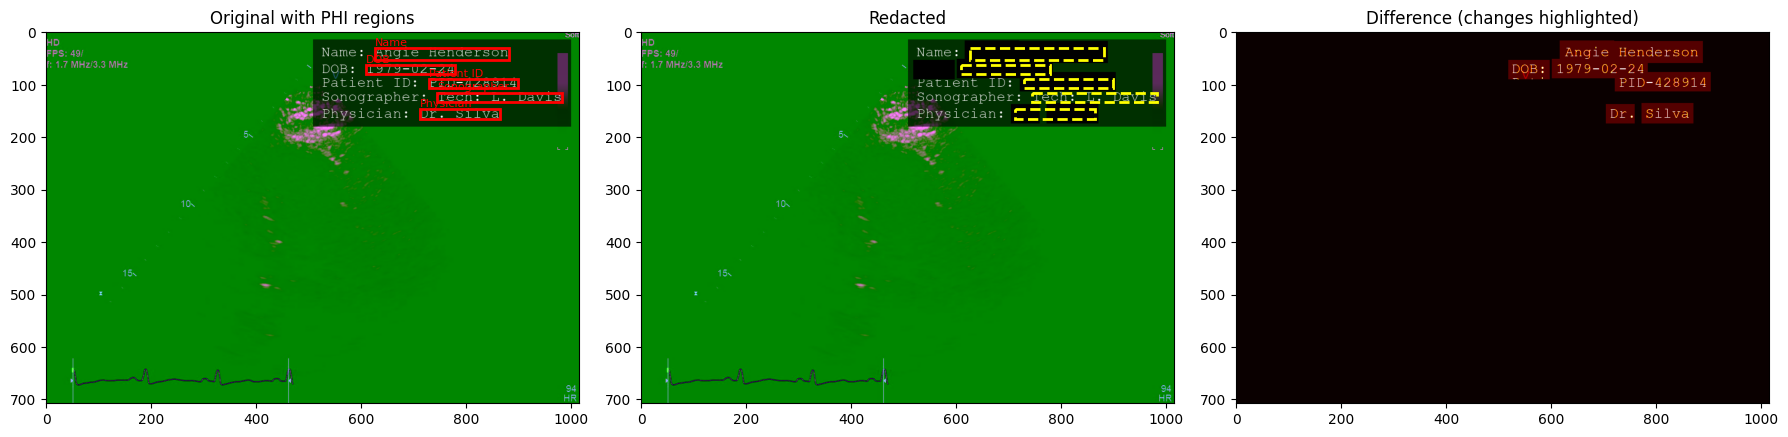


PHI Annotations:


,field,text,x,y,width,height
125,Name,Angie Henderson,627,30,255,23
126,DOB,1979-02-24,610,63,170,17
127,Patient ID,PID-428914,729,89,170,17
128,Sonographer,Tech: L. Davis,746,115,238,18
129,Physician,Dr. Silva,712,147,153,18


In [60]:
# Visualize the worst image file automatically
if not problematic.empty and IMAGES_AVAILABLE:
    image_problems = problematic[problematic['type'] == 'image']
    if not image_problems.empty:
        worst_image = image_problems.sort_values('mean_coverage').iloc[0]
        print(f"Visualizing worst image file: {worst_image['filename']}")
        print(f"Patient: {worst_image['patient']}")
        print(f"Coverage: {worst_image['mean_coverage']:.2%}")
        
        # Determine modality from filename
        if 'echo' in worst_image['filename'].lower():
            modality = 'echo'
        elif 'cxr' in worst_image['filename'].lower():
            modality = 'cxr'
        else:
            modality = 'ecg'
        
        visualize_image_redaction(worst_image['patient'], worst_image['filename'], modality=modality)

## 5. Summary Statistics

In [61]:
# Summary statistics by file type and patient
pivot_df = details_df.pivot_table(
    index=['patient', 'type', 'filename'],
    columns='metric',
    values='value',
    aggfunc='first'
).reset_index()

for col in ['recall', 'mean_coverage', 'false_negatives', 'not_covered']:
    if col in pivot_df.columns:
        pivot_df[col] = pd.to_numeric(pivot_df[col], errors='coerce')

print("=" * 60)
print("SUMMARY BY FILE TYPE")
print("=" * 60)

for file_type in pivot_df['type'].unique():
    type_df = pivot_df[pivot_df['type'] == file_type]
    print(f"\n{file_type.upper()}:")
    print(f"  Files: {len(type_df)}")
    if 'recall' in type_df.columns and type_df['recall'].notna().any():
        print(f"  Mean recall: {type_df['recall'].mean():.2%}")
        print(f"  Min recall: {type_df['recall'].min():.2%}")
        print(f"  Files < {RECALL_THRESHOLD:.0%}: {(type_df['recall'] < RECALL_THRESHOLD).sum()}")
    if 'mean_coverage' in type_df.columns and type_df['mean_coverage'].notna().any():
        print(f"  Mean coverage: {type_df['mean_coverage'].mean():.2%}")
        print(f"  Min coverage: {type_df['mean_coverage'].min():.2%}")
        print(f"  Files < {COVERAGE_THRESHOLD:.0%}: {(type_df['mean_coverage'] < COVERAGE_THRESHOLD).sum()}")

SUMMARY BY FILE TYPE

CSV:
  Files: 39
  Mean recall: 99.68%
  Min recall: 92.33%
  Files < 99%: 2

FILENAME:
  Files: 56

HEA:
  Files: 4
  Mean recall: 100.00%
  Min recall: 100.00%
  Files < 99%: 0

IMAGE:
  Files: 48
  Mean coverage: 98.80%
  Min coverage: 78.30%
  Files < 95%: 5

PDF:
  Files: 4
  Mean coverage: 99.11%
  Min coverage: 96.43%
  Files < 95%: 0


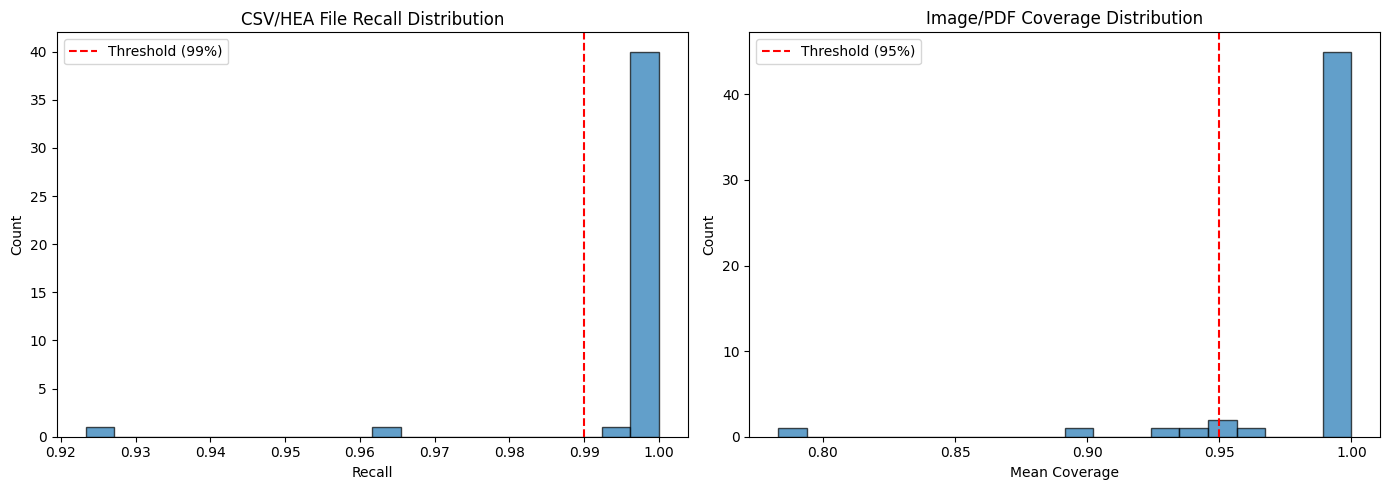

In [62]:
# Distribution of recall/coverage
if IMAGES_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # CSV Recall distribution
    csv_recall = pivot_df[pivot_df['type'].isin(['csv', 'hea'])]['recall'].dropna()
    if len(csv_recall) > 0:
        axes[0].hist(csv_recall, bins=20, edgecolor='black', alpha=0.7)
        axes[0].axvline(x=RECALL_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({RECALL_THRESHOLD:.0%})')
        axes[0].set_xlabel('Recall')
        axes[0].set_ylabel('Count')
        axes[0].set_title('CSV/HEA File Recall Distribution')
        axes[0].legend()
    
    # Image Coverage distribution
    img_coverage = pivot_df[pivot_df['type'].isin(['image', 'pdf'])]['mean_coverage'].dropna()
    if len(img_coverage) > 0:
        axes[1].hist(img_coverage, bins=20, edgecolor='black', alpha=0.7)
        axes[1].axvline(x=COVERAGE_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({COVERAGE_THRESHOLD:.0%})')
        axes[1].set_xlabel('Mean Coverage')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Image/PDF Coverage Distribution')
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 6. Export Issues for Further Analysis

In [63]:
# Export all CSV issues to a file for detailed review
# This can take a while for large datasets

# Uncomment to run:
# all_csv_issues = get_all_csv_issues()
# if not all_csv_issues.empty:
#     output_path = "data/results_eval/csv_issues_detailed.csv"
#     all_csv_issues.to_csv(output_path, index=False)
#     print(f"Exported {len(all_csv_issues)} issues to {output_path}")

In [64]:
# Quick helper to list available patients and files
def list_available_data():
    """List available patients and their file counts."""
    folder_mapping_path = os.path.join(RESULTS_DIR, 'folder_anonymization.csv')
    if not os.path.exists(folder_mapping_path):
        print(f"Error: {folder_mapping_path} not found")
        return
    
    folder_map = pd.read_csv(folder_mapping_path)
    
    print("Available patients:")
    print("=" * 80)
    
    for _, row in folder_map.iterrows():
        patient = row['original_foldername']
        anon_patient = row['anonymized_foldername']
        print(f"\n{patient} -> {anon_patient}")
        
        # Count files by modality
        for modality in ['csv', 'cxr', 'ecg', 'echo']:
            modality_dir = os.path.join(RESULTS_DIR, anon_patient, modality)
            if os.path.exists(modality_dir):
                files = [f for f in os.listdir(modality_dir) 
                        if not f.startswith('filename_') and not f.startswith('.')]
                if files:
                    print(f"  {modality}: {len(files)} files")

list_available_data()

Available patients:

patient_10005749_20010003 -> patient_ID_ID_001
  csv: 15 files
  cxr: 2 files
  ecg: 2 files

patient_10080695_23273240 -> patient_ID_ID_002
  csv: 24 files
  ecg: 3 files
  echo: 46 files
